In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive\student_performance_dataset.csv")

print(f"📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔍 First 5 rows:")
df.head()

📊 Dataset Shape: 708 rows × 10 columns

🔍 First 5 rows:


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [6]:
print("📋 Column Info:")
df.info()
print("\n📈 Statistical Summary:")
df.describe().round(2)

📋 Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB

📈 Statistical Summary:


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.00,708.00,708.00,708.00
mean,26.13,78.11,77.87,58.77
std,8.88,13.80,14.40,6.71
min,10.00,50.12,50.00,50.00
25%,19.00,67.55,65.00,52.00
50%,27.00,79.36,79.00,59.50
75%,34.00,89.50,91.00,64.00
max,39.00,99.97,100.00,77.00


In [7]:
missing = df.isnull().sum()
print("🔎 Missing Values:")
print(missing)
print(f"\n✅ Total missing values: {missing.sum()}")

🔎 Missing Values:
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

✅ Total missing values: 0


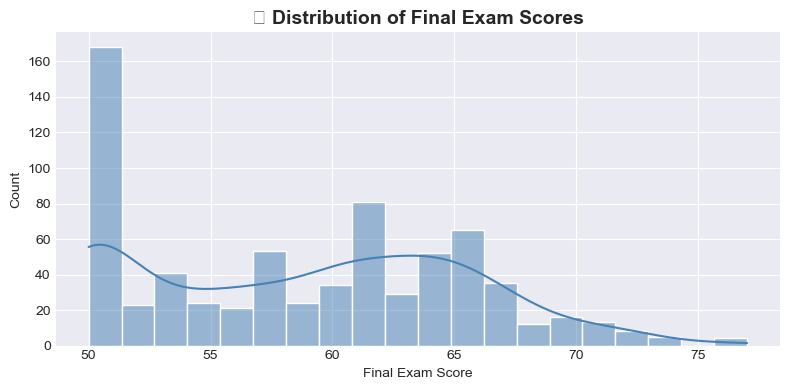

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Final_Exam_Score'], bins=20, kde=True, color='steelblue', edgecolor='white')
plt.title('📊 Distribution of Final Exam Scores', fontsize=14, fontweight='bold')
plt.xlabel('Final Exam Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

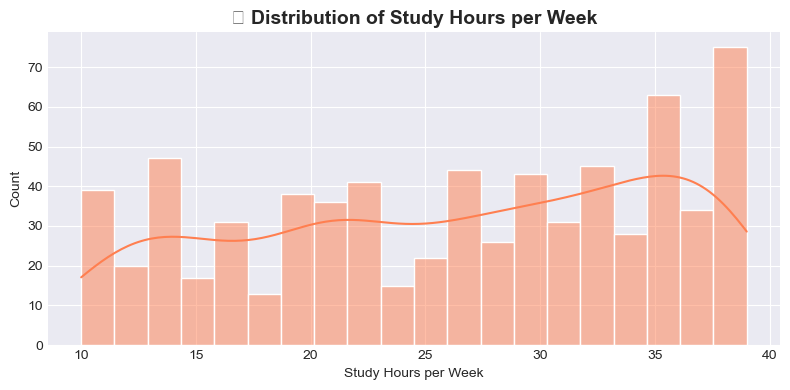

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Study_Hours_per_Week'], bins=20, kde=True, color='coral', edgecolor='white')
plt.title('📚 Distribution of Study Hours per Week', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours per Week')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


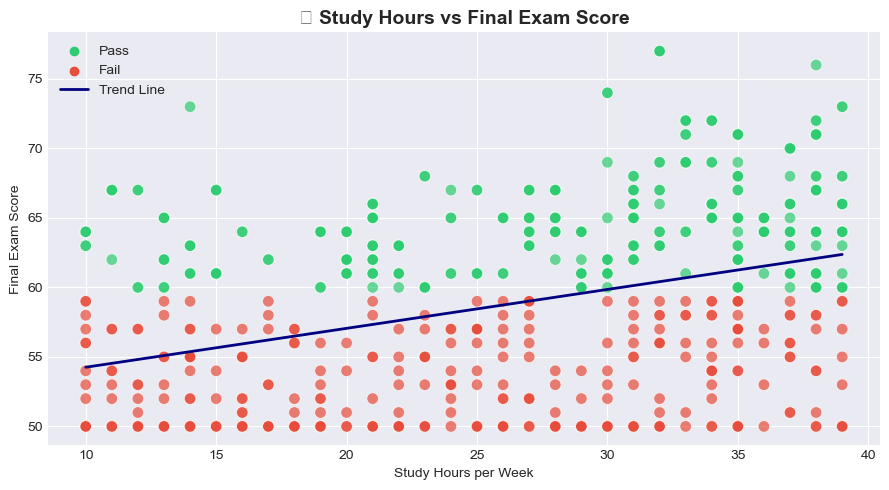

📌 Correlation: 0.3704


In [10]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='Final_Exam_Score',
                hue='Pass_Fail',
                palette={'Pass': '#2ecc71', 'Fail': '#e74c3c'},
                alpha=0.7, s=70)

m, b = np.polyfit(df['Study_Hours_per_Week'], df['Final_Exam_Score'], 1)
x_line = np.linspace(df['Study_Hours_per_Week'].min(), df['Study_Hours_per_Week'].max(), 100)
plt.plot(x_line, m * x_line + b, color='navy', linewidth=2, label='Trend Line')
plt.title('📖 Study Hours vs Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Exam Score')
plt.legend()
plt.tight_layout()
plt.show()
corr = df['Study_Hours_per_Week'].corr(df['Final_Exam_Score'])
print(f"📌 Correlation: {corr:.4f}")


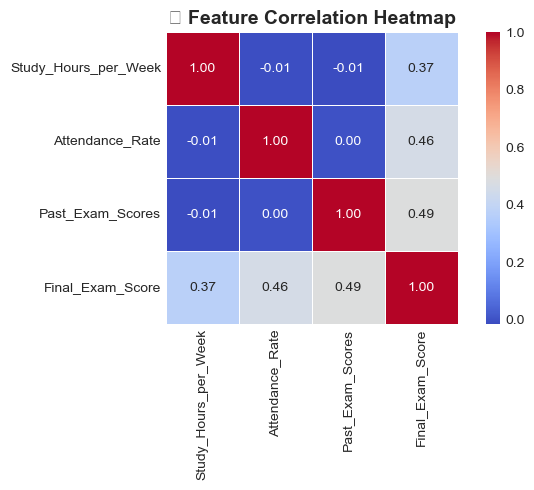

In [11]:
num_cols = ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Final_Exam_Score']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
X = df[['Study_Hours_per_Week']]   # Feature
y = df['Final_Exam_Score']          # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Feature shape: {X.shape}")
print(f"🏋️  Training samples: {X_train.shape[0]}")
print(f"🧪 Testing samples : {X_test.shape[0]}")

✅ Feature shape: (708, 1)
🏋️  Training samples: 566
🧪 Testing samples : 142


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print("🤖 Model Trained Successfully!")
print(f"\n📐 Equation:")
print(f"   Final_Score = {model.coef_[0]:.4f} × Study_Hours + {model.intercept_:.4f}")
print(f"\n📌 Every extra study hour adds ≈ {model.coef_[0]:.2f} marks")

🤖 Model Trained Successfully!

📐 Equation:
   Final_Score = 0.2596 × Study_Hours + 51.9610

📌 Every extra study hour adds ≈ 0.26 marks


In [14]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("="*50)
print("        📊 MODEL EVALUATION RESULTS")
print("="*50)
print(f"  MAE   : {mae:.2f}")
print(f"  MSE   : {mse:.2f}")
print(f"  RMSE  : {rmse:.2f}")
print(f"  R²    : {r2:.4f}  ({r2*100:.2f}%)")
print("="*50)

        📊 MODEL EVALUATION RESULTS
  MAE   : 5.06
  MSE   : 33.14
  RMSE  : 5.76
  R²    : 0.2210  (22.10%)


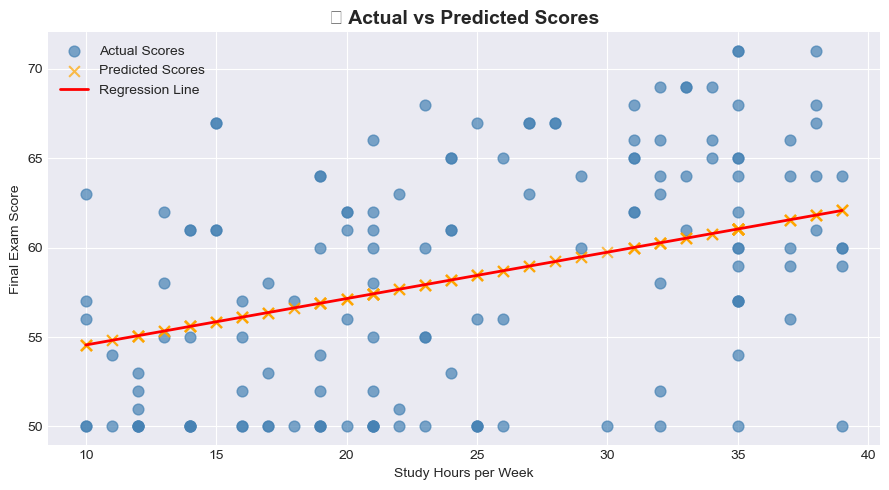

In [15]:
plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test,  color='steelblue', label='Actual Scores',    alpha=0.7, s=60)
plt.scatter(X_test, y_pred,  color='orange',    label='Predicted Scores', alpha=0.7, s=60, marker='x')

x_range = np.linspace(X['Study_Hours_per_Week'].min(), X['Study_Hours_per_Week'].max(), 200).reshape(-1,1)
plt.plot(x_range, model.predict(x_range), color='red', linewidth=2, label='Regression Line')

plt.title('🎯 Actual vs Predicted Scores', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
study_hours_input = 4
predicted_score   = model.predict([[study_hours_input]])[0]

print("="*50)
print("           🔮 PREDICTION RESULT")
print("="*50)
print(f"  Input  → Study Hours     : {study_hours_input} hrs/week")
print(f"  Output → Predicted Score : {predicted_score:.2f} / 100")
print("="*50)

if predicted_score >= 55:
    print("  Result: Pass ✅")
else:
    print("  Result: Fail ❌  (Needs more study hours!)")
print("="*50)

           🔮 PREDICTION RESULT
  Input  → Study Hours     : 4 hrs/week
  Output → Predicted Score : 53.00 / 100
  Result: Fail ❌  (Needs more study hours!)


In [17]:
test_hours = [2, 4, 6, 8, 10, 15, 20, 25, 30, 35, 40]
preds = model.predict([[h] for h in test_hours])

results_df = pd.DataFrame({
    'Study_Hours': test_hours,
    'Predicted_Score': np.round(preds, 2),
    'Result': ['Pass ✅' if p >= 55 else 'Fail ❌' for p in preds]
})
print("📋 Prediction Table:")
print(results_df.to_string(index=False))

📋 Prediction Table:
 Study_Hours  Predicted_Score Result
           2            52.48 Fail ❌
           4            53.00 Fail ❌
           6            53.52 Fail ❌
           8            54.04 Fail ❌
          10            54.56 Fail ❌
          15            55.85 Pass ✅
          20            57.15 Pass ✅
          25            58.45 Pass ✅
          30            59.75 Pass ✅
          35            61.05 Pass ✅
          40            62.34 Pass ✅


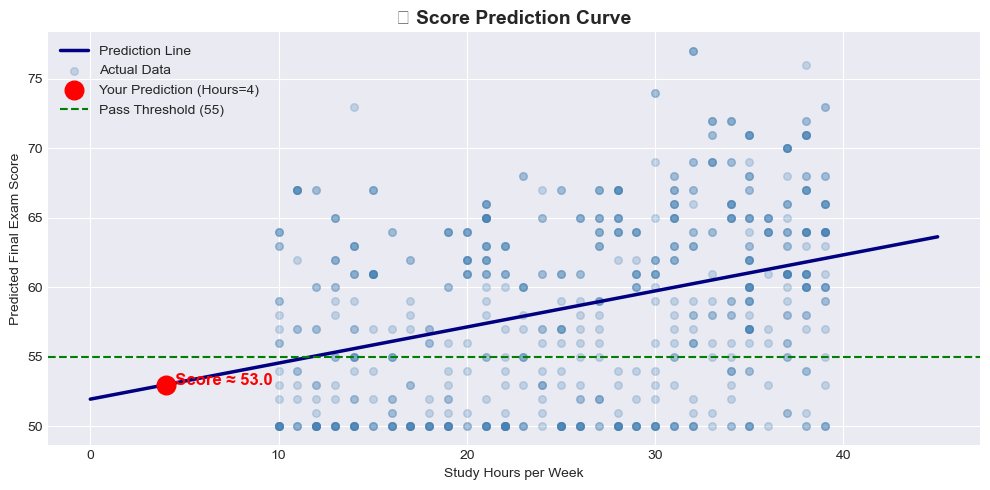

In [18]:
hours_range = np.linspace(0, 45, 300).reshape(-1, 1)
score_range = model.predict(hours_range)

plt.figure(figsize=(10, 5))
plt.plot(hours_range, score_range, color='navy', linewidth=2.5, label='Prediction Line')
plt.scatter(df['Study_Hours_per_Week'], df['Final_Exam_Score'],
            alpha=0.25, color='steelblue', s=30, label='Actual Data')
plt.scatter([study_hours_input], [predicted_score],
            color='red', s=180, zorder=5, label=f'Your Prediction (Hours={study_hours_input})')
plt.annotate(f'  Score ≈ {predicted_score:.1f}',
             xy=(study_hours_input, predicted_score),
             fontsize=12, color='red', fontweight='bold')
plt.axhline(y=55, color='green', linestyle='--', linewidth=1.5, label='Pass Threshold (55)')
plt.title('🔮 Score Prediction Curve', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours per Week')
plt.ylabel('Predicted Final Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
print("="*50)
print("  🎉 PROJECT COMPLETE!")
print("="*50)
print()
print("  📌 Summary:")
print(f"  Model      : Linear Regression")
print(f"  Feature    : Study Hours per Week")
print(f"  Target     : Final Exam Score")
print(f"  MAE        : {mae:.2f}")
print(f"  R² Score   : {r2:.4f}")
print()
print("  ✅ GitHub → upload notebook")
print("  ✅ Video  → record 2-3 min explanation")
print("  ✅ LinkedIn → post + tag Learn Depth")
print("  ⏰ Deadline: March 3")


  🎉 PROJECT COMPLETE!

  📌 Summary:
  Model      : Linear Regression
  Feature    : Study Hours per Week
  Target     : Final Exam Score
  MAE        : 5.06
  R² Score   : 0.2210

  ✅ GitHub → upload notebook
  ✅ Video  → record 2-3 min explanation
  ✅ LinkedIn → post + tag Learn Depth
  ⏰ Deadline: March 3
